# ESM-2 Protein Embedding Analysis

This notebook provides a reproducible end-to-end workflow for:

1. Loading and cleaning the protein dataset.
2. Creating **one fixed stratified train/validation/test split**.
3. Generating ESM-2 protein embeddings.
4. Storing embeddings without variable-index or stale-kernel problems.
5. Analysing embedding geometry and class structure.
6. Comparing ESM-2 1280D, PCA-256, and a supervised learned 256D projection.
7. Training classifiers with validation and early stopping.
8. Evaluating the final models only once on the held-out test set.



## 1. Install required packages




In [1]:
#!pip install -q transformers scikit-learn umap-learn seaborn


## 2. Imports and reproducibility


In [2]:
import os
import gc
import copy
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, silhouette_score
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import umap.umap_ as umap

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)


Device: mps


## 3. Load and clean the dataset

The dataset is balanced to **6,000 proteins per class**, producing 30,000 proteins in total.


In [8]:
DATA_PATH = "proteins_kaggle/proteinas_20000_enriquecido.csv"

data = pd.read_csv(DATA_PATH, index_col=0)
data = data.dropna().copy()

data = data.rename(columns={"Sequência":"Sequence","Massa_Molecular":"Molecular_Weight","Ponto_Isoelétrico":"Isoelectric_Point","Hidrofobicidade":"Hydrophobicity","Carga_Total":"Total_Charge","Proporção_Polar":"Polar_Proportion","Proporção_Apolar":"Nonpolar_Proportion","Comprimento_Sequência":"Sequence_Length","Classe":"class"})
data.index.name = "Protein_ID"

valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

def clean_sequence(sequence):
    sequence = str(sequence).strip().upper()
    return "".join([aa for aa in sequence if aa in valid_amino_acids])

data["Sequence"] = data["Sequence"].map(clean_sequence)
data = data[data["Sequence"].str.len() > 0].copy()

balanced_data = data.groupby("class", group_keys=False).apply(lambda x: x.sample(n=min(6000,len(x)),random_state=SEED)).reset_index()
balanced_data = balanced_data.rename(columns={"index":"Protein_ID"})
balanced_data = balanced_data.set_index("Protein_ID")
balanced_data.index.name = "Protein_ID"

print("Dataset shape:", balanced_data.shape)
print("\nClass counts:")
print(balanced_data["class"].value_counts())
print("\nSequence length summary:")
print(balanced_data["Sequence"].str.len().describe())


Dataset shape: (30000, 9)

Class counts:
class
Enzima        6000
Estrutural    6000
Outras        6000
Receptora     6000
Transporte    6000
Name: count, dtype: int64

Sequence length summary:
count    30000.000000
mean       175.046367
std         72.281686
min         50.000000
25%        113.000000
50%        175.000000
75%        237.000000
max        300.000000
Name: Sequence, dtype: float64


## 4. Create exactly one train/validation/test split

The split is:

- Train: 19,200
- Validation: 4,800
- Test: 6,000

The indices are created once and then used everywhere in the notebook. This prevents mismatches between embeddings and labels.


In [9]:
all_positions = np.arange(len(balanced_data))
all_labels = balanced_data["class"].to_numpy()

train_idx, test_idx = train_test_split(all_positions,test_size=0.20,random_state=SEED,stratify=all_labels)
train_idx, val_idx = train_test_split(train_idx,test_size=0.20,random_state=SEED,stratify=all_labels[train_idx])

train_idx = np.sort(train_idx)
val_idx = np.sort(val_idx)
test_idx = np.sort(test_idx)

assert len(train_idx) == 19200
assert len(val_idx) == 4800
assert len(test_idx) == 6000
assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0
assert len(np.concatenate([train_idx,val_idx,test_idx])) == len(balanced_data)

MASTER_DIR = Path("/kaggle/working/esm2_clean")
MASTER_DIR.mkdir(parents=True,exist_ok=True)

np.save(MASTER_DIR / "train_indices.npy",train_idx)
np.save(MASTER_DIR / "val_indices.npy",val_idx)
np.save(MASTER_DIR / "test_indices.npy",test_idx)

train_labels_raw = all_labels[train_idx]
val_labels_raw = all_labels[val_idx]
test_labels_raw = all_labels[test_idx]

np.save(MASTER_DIR / "train_labels.npy",train_labels_raw)
np.save(MASTER_DIR / "val_labels.npy",val_labels_raw)
np.save(MASTER_DIR / "test_labels.npy",test_labels_raw)

print("Train:",len(train_idx))
print("Validation:",len(val_idx))
print("Test:",len(test_idx))


OSError: [Errno 30] Read-only file system: '/kaggle'

## 5. Encode labels using the training set only


In [5]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_labels_raw)
y_val = label_encoder.transform(val_labels_raw)
y_test = label_encoder.transform(test_labels_raw)

class_names = label_encoder.classes_
num_classes = len(class_names)

print("Classes:",class_names)
print("Number of classes:",num_classes)


Classes: ['Enzima' 'Estrutural' 'Outras' 'Receptora' 'Transporte']
Number of classes: 5


## 6. Load ESM-2

ESM-2 is used as a frozen feature extractor. The language-model weights are not fine-tuned in this notebook.


In [6]:
MODEL_NAME = "facebook/esm2_t33_650M_UR50D"
MAX_LENGTH = 512
EMBEDDING_DIM = 1280
EMBEDDING_BATCH_SIZE = 4

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
esm_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
esm_model.eval()

print("Model:",MODEL_NAME)
print("Hidden size:",esm_model.config.hidden_size)
print("Layers:",esm_model.config.num_hidden_layers)
print("Parameters:",sum(p.numel() for p in esm_model.parameters()))


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: facebook/esm2_t33_650M_UR50D
Hidden size: 1280
Layers: 33
Parameters: 651040661


## 7. ESM-2 embedding function

Mean pooling is performed over **residue tokens only**. BOS/EOS special tokens are excluded.

Proteins longer than `MAX_LENGTH - 2` tokens are truncated. The number of truncated proteins is reported before embedding generation.


In [7]:
@torch.inference_mode()
def embed_batch_with_esm2(sequences,max_length=MAX_LENGTH):
    clean_sequences = [str(sequence).strip().upper() for sequence in sequences]
    inputs = tokenizer(clean_sequences,return_tensors="pt",padding=True,truncation=True,max_length=max_length)
    inputs = {key:value.to(device) for key,value in inputs.items()}
    outputs = esm_model(**inputs)
    hidden = outputs.last_hidden_state
    attention_mask = inputs["attention_mask"]
    embeddings = []

    for row in range(hidden.size(0)):
        valid_length = int(attention_mask[row].sum().item())
        residue_hidden = hidden[row,1:max(valid_length-1,1),:]
        embeddings.append(residue_hidden.mean(dim=0).float().cpu().numpy())

    return np.asarray(embeddings,dtype=np.float32)

too_long_count = int((balanced_data["Sequence"].str.len() > MAX_LENGTH - 2).sum())
print("Proteins longer than",MAX_LENGTH - 2,"residues:",too_long_count)


Proteins longer than 510 residues: 0


## 8. Generate and store the master embedding matrix

A NumPy memory-mapped file is used instead of repeatedly recreating Zarr stores. The row number always corresponds to the row position in `balanced_data`.


In [8]:
EMBEDDING_PATH = MASTER_DIR / "esm2_embeddings.float16.dat"
embedding_memmap = np.memmap(EMBEDDING_PATH,dtype="float16",mode="w+",shape=(len(balanced_data),EMBEDDING_DIM))

all_sequences = balanced_data["Sequence"].to_numpy()
start_time = time.time()

for start in tqdm(range(0,len(all_sequences),EMBEDDING_BATCH_SIZE),desc="Generating ESM-2 embeddings"):
    stop = min(start + EMBEDDING_BATCH_SIZE,len(all_sequences))
    batch_embeddings = embed_batch_with_esm2(all_sequences[start:stop])
    if batch_embeddings.shape != (stop-start,EMBEDDING_DIM):
        raise ValueError(f"Unexpected embedding shape: {batch_embeddings.shape}")
    embedding_memmap[start:stop] = batch_embeddings.astype(np.float16)

embedding_memmap.flush()
elapsed = time.time() - start_time

print(f"Embedding generation time: {elapsed/60:.2f} minutes")
print("Embedding matrix:",embedding_memmap.shape)
print("Stored dtype:",embedding_memmap.dtype)


Generating ESM-2 embeddings:   0%|          | 0/7500 [00:00<?, ?it/s]

Embedding generation time: 66.30 minutes
Embedding matrix: (30000, 1280)
Stored dtype: float16


## 9. Load the three splits from the same master matrix

This is the only place where train, validation, and test embeddings are created.


In [9]:
embeddings = np.memmap(EMBEDDING_PATH,dtype="float16",mode="r",shape=(len(balanced_data),EMBEDDING_DIM))

X_train = np.asarray(embeddings[train_idx],dtype=np.float32)
X_val = np.asarray(embeddings[val_idx],dtype=np.float32)
X_test = np.asarray(embeddings[test_idx],dtype=np.float32)

assert X_train.shape[0] == len(y_train)
assert X_val.shape[0] == len(y_val)
assert X_test.shape[0] == len(y_test)
assert X_train.shape[1] == EMBEDDING_DIM
assert X_val.shape[1] == EMBEDDING_DIM
assert X_test.shape[1] == EMBEDDING_DIM

print("X_train:",X_train.shape)
print("X_val:",X_val.shape)
print("X_test:",X_test.shape)


X_train: (19200, 1280)
X_val: (4800, 1280)
X_test: (6000, 1280)


# Embedding Analysis

The following analyses examine the embedding space before supervised classification.

### Analysis methods included

- Embedding norms
- Feature variance
- PCA explained variance
- Class-centroid distances
- Cosine similarity
- Nearest-neighbour label agreement
- K-means clustering and silhouette score
- UMAP visualization
- t-SNE visualization
- Linear-probe classification

These are useful for determining whether proteins from the same class occupy coherent regions of embedding space.


## 10. Basic embedding statistics


In [10]:
embedding_norms = np.linalg.norm(X_train,axis=1)
feature_variance = np.var(X_train,axis=0)

print("Embedding norm mean:",embedding_norms.mean())
print("Embedding norm std:",embedding_norms.std())
print("Embedding norm min:",embedding_norms.min())
print("Embedding norm max:",embedding_norms.max())
print("Mean feature variance:",feature_variance.mean())
print("Near-zero variance features:",int(np.sum(feature_variance < 1e-8)))


Embedding norm mean: 9.82375
Embedding norm std: 0.15987518
Embedding norm min: 8.550552
Embedding norm max: 10.197218
Mean feature variance: 0.002237397
Near-zero variance features: 0


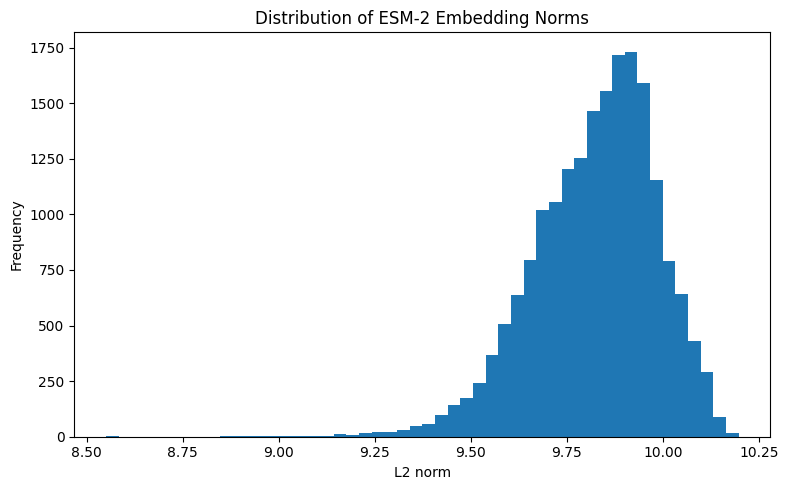

In [11]:
plt.figure(figsize=(8,5))
plt.hist(embedding_norms,bins=50)
plt.xlabel("L2 norm")
plt.ylabel("Frequency")
plt.title("Distribution of ESM-2 Embedding Norms")
plt.tight_layout()
plt.show()


## 11. PCA analysis of the original ESM-2 embedding

PCA is fitted on training embeddings only. The explained variance indicates how much information/variance is retained by lower-dimensional representations.


In [12]:
PCA_ANALYSIS_COMPONENTS = min(256,X_train.shape[1])
pca_analysis = IncrementalPCA(n_components=PCA_ANALYSIS_COMPONENTS,batch_size=512)
pca_analysis.fit(X_train)

cumulative_variance = np.cumsum(pca_analysis.explained_variance_ratio_)

print("Variance retained by 32 components:",cumulative_variance[31])
print("Variance retained by 64 components:",cumulative_variance[63])
print("Variance retained by 128 components:",cumulative_variance[127])
print("Variance retained by 256 components:",cumulative_variance[255])


Variance retained by 32 components: 0.8437602238925137
Variance retained by 64 components: 0.916084844858804
Variance retained by 128 components: 0.9521381476847869
Variance retained by 256 components: 0.9732617483536062


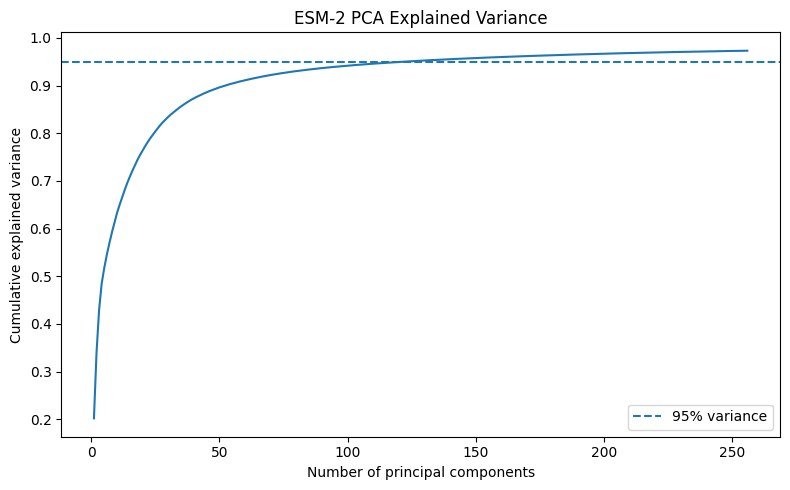

In [13]:
plt.figure(figsize=(8,5))
plt.plot(np.arange(1,PCA_ANALYSIS_COMPONENTS+1),cumulative_variance)
plt.axhline(0.95,linestyle="--",label="95% variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("ESM-2 PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Class-centroid analysis

Class centroids show whether proteins from different functional classes occupy different regions of embedding space.


In [14]:
class_centroids = np.vstack([X_train[y_train == class_id].mean(axis=0) for class_id in range(num_classes)])

centroid_norms = np.linalg.norm(class_centroids,axis=1)
cosine_centroids = (class_centroids @ class_centroids.T) / np.outer(centroid_norms,centroid_norms)
centroid_distance = np.linalg.norm(class_centroids[:,None,:] - class_centroids[None,:,:],axis=2)

print("Centroid cosine similarity:")
print(pd.DataFrame(cosine_centroids,index=class_names,columns=class_names).round(3))
print("\nCentroid Euclidean distance:")
print(pd.DataFrame(centroid_distance,index=class_names,columns=class_names).round(3))


Centroid cosine similarity:
            Enzima  Estrutural  Outras  Receptora  Transporte
Enzima         1.0         1.0     1.0        1.0         1.0
Estrutural     1.0         1.0     1.0        1.0         1.0
Outras         1.0         1.0     1.0        1.0         1.0
Receptora      1.0         1.0     1.0        1.0         1.0
Transporte     1.0         1.0     1.0        1.0         1.0

Centroid Euclidean distance:
            Enzima  Estrutural  Outras  Receptora  Transporte
Enzima       0.000       0.048   0.047      0.052       0.034
Estrutural   0.048       0.000   0.033      0.028       0.033
Outras       0.047       0.033   0.000      0.036       0.035
Receptora    0.052       0.028   0.036      0.000       0.038
Transporte   0.034       0.033   0.035      0.038       0.000


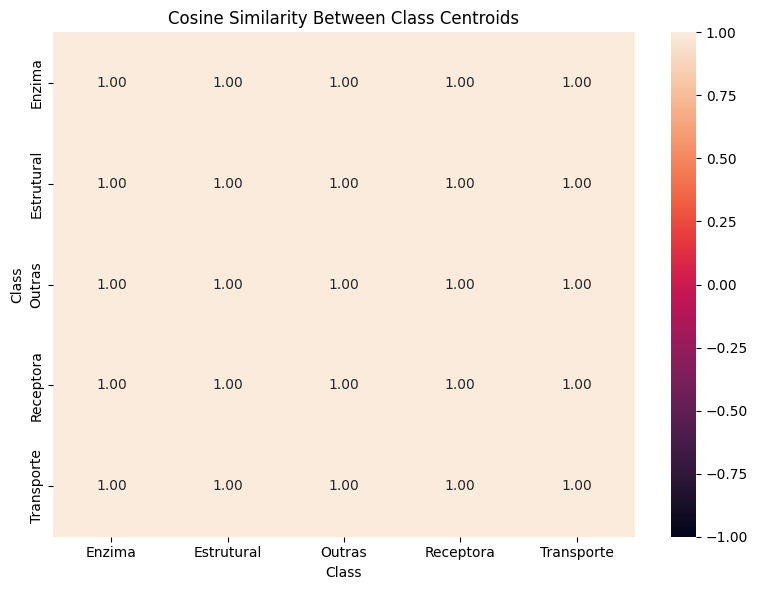

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(cosine_centroids,xticklabels=class_names,yticklabels=class_names,annot=True,fmt=".2f",vmin=-1,vmax=1)
plt.title("Cosine Similarity Between Class Centroids")
plt.xlabel("Class")
plt.ylabel("Class")
plt.tight_layout()
plt.show()


## 13. Cosine nearest-neighbour analysis

Nearest-neighbour label agreement is an intrinsic embedding-space measure. If same-class proteins frequently occur near one another, the embedding contains local class structure.

The calculation below uses a sample to keep memory requirements manageable.


In [16]:
from sklearn.metrics import pairwise_distances

NN_SAMPLE_SIZE = min(3000,len(X_train))
rng = np.random.default_rng(SEED)
nn_sample_idx = rng.choice(len(X_train),size=NN_SAMPLE_SIZE,replace=False)
X_nn = X_train[nn_sample_idx]
y_nn = y_train[nn_sample_idx]

X_nn_norm = X_nn / np.clip(np.linalg.norm(X_nn,axis=1,keepdims=True),1e-12,None)
cosine_distance = pairwise_distances(X_nn_norm,metric="cosine")
np.fill_diagonal(cosine_distance,np.inf)

nearest_idx = np.argmin(cosine_distance,axis=1)
nn_accuracy = np.mean(y_nn[nearest_idx] == y_nn)

print("Nearest-neighbour class agreement:",nn_accuracy)


Nearest-neighbour class agreement: 0.20266666666666666


## 14. K-means clustering and silhouette analysis

Clustering is performed on a PCA representation to make the distance calculations more stable and efficient.


In [17]:
X_train_pca_analysis = pca_analysis.transform(X_train[:,]).astype(np.float32)
CLUSTER_SAMPLE_SIZE = min(5000,len(X_train_pca_analysis))
cluster_idx = rng.choice(len(X_train_pca_analysis),size=CLUSTER_SAMPLE_SIZE,replace=False)
X_cluster = X_train_pca_analysis[cluster_idx]
y_cluster = y_train[cluster_idx]

kmeans = KMeans(n_clusters=num_classes,random_state=SEED,n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

silhouette = silhouette_score(X_cluster,cluster_labels)
cluster_table = pd.crosstab(cluster_labels,y_cluster,rownames=["Cluster"],colnames=["True class"])

print("Silhouette score:",silhouette)
print("\nCluster/class contingency table:")
print(cluster_table)


Silhouette score: 0.11221638

Cluster/class contingency table:
True class    0    1    2    3    4
Cluster                            
0           236  254  223  232  206
1           214  212  203  209  192
2           141  151  154  127  137
3           371  346  321  340  349
4            73   76   93   66   74


## 15. UMAP visualization

UMAP provides a 2D visualization of local and global structure. It is used for exploration, not as a quantitative replacement for the classifier.


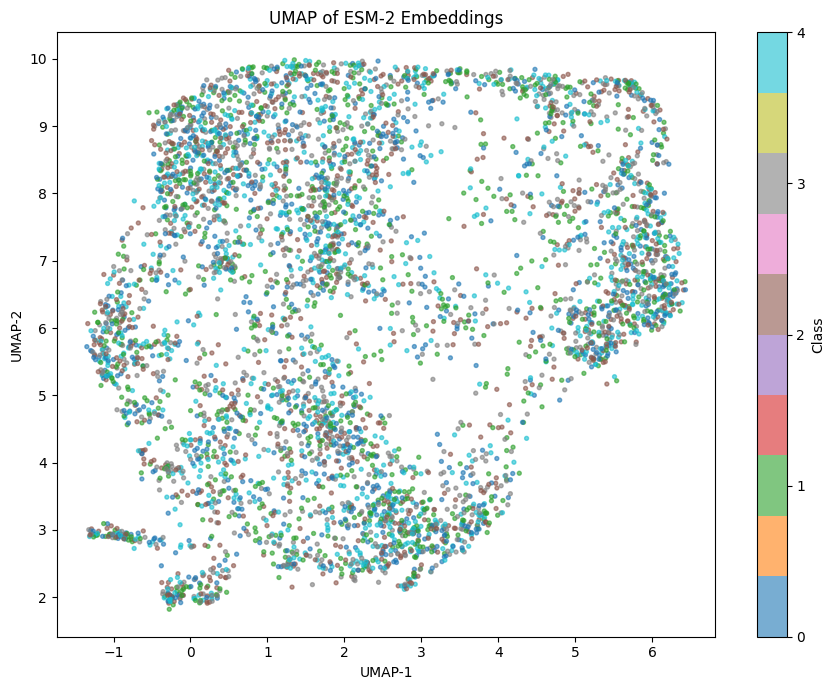

In [18]:
UMAP_SAMPLE_SIZE = min(5000,len(X_train_pca_analysis))
umap_idx = rng.choice(len(X_train_pca_analysis),size=UMAP_SAMPLE_SIZE,replace=False)

umap_model = umap.UMAP(n_neighbors=30,min_dist=0.1,n_components=2,metric="cosine",random_state=SEED)
X_umap = umap_model.fit_transform(X_train_pca_analysis[umap_idx])

plt.figure(figsize=(9,7))
scatter = plt.scatter(X_umap[:,0],X_umap[:,1],c=y_train[umap_idx],s=8,alpha=0.6,cmap="tab10")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of ESM-2 Embeddings")
plt.colorbar(scatter,ticks=np.arange(num_classes),label="Class")
plt.tight_layout()
plt.show()


## 16. t-SNE visualization

t-SNE is another exploratory visualization method. It is applied to PCA-reduced embeddings to reduce computational cost.


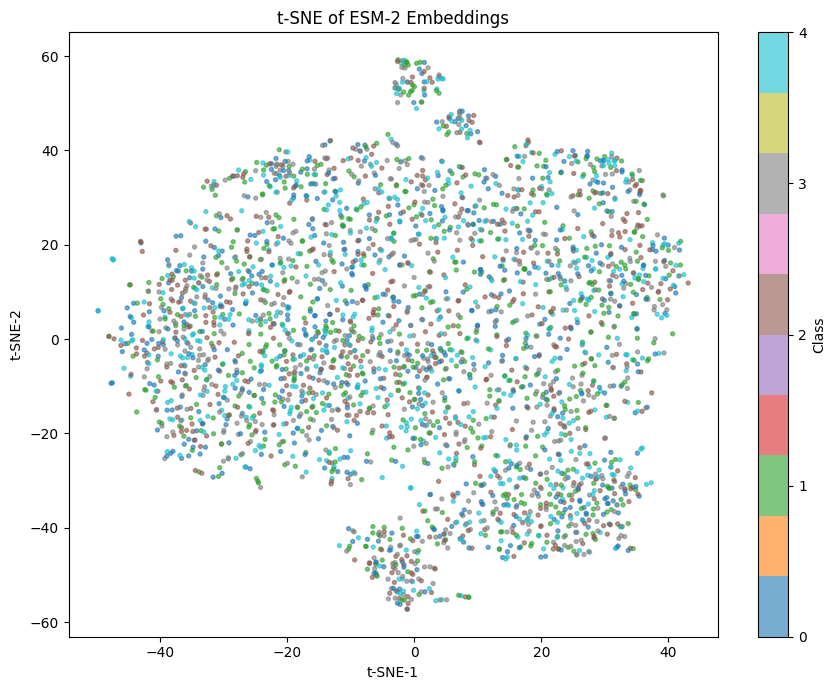

In [19]:
TSNE_SAMPLE_SIZE = min(3000,len(X_train_pca_analysis))
tsne_idx = rng.choice(len(X_train_pca_analysis),size=TSNE_SAMPLE_SIZE,replace=False)

tsne_model = TSNE(n_components=2,perplexity=30,init="pca",learning_rate="auto",random_state=SEED)
X_tsne = tsne_model.fit_transform(X_train_pca_analysis[tsne_idx])

plt.figure(figsize=(9,7))
scatter = plt.scatter(X_tsne[:,0],X_tsne[:,1],c=y_train[tsne_idx],s=8,alpha=0.6,cmap="tab10")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.title("t-SNE of ESM-2 Embeddings")
plt.colorbar(scatter,ticks=np.arange(num_classes),label="Class")
plt.tight_layout()
plt.show()


# Dimensionality Reduction

## 17. PCA-256 representation

PCA is fitted only on the training set. The same fitted transformation is applied to validation and test data.


In [20]:
PCA_DIM = 256
pca = IncrementalPCA(n_components=PCA_DIM,batch_size=512)
pca.fit(X_train)

X_train_pca = pca.transform(X_train).astype(np.float32)
X_val_pca = pca.transform(X_val).astype(np.float32)
X_test_pca = pca.transform(X_test).astype(np.float32)

print("X_train_pca:",X_train_pca.shape)
print("X_val_pca:",X_val_pca.shape)
print("X_test_pca:",X_test_pca.shape)
print("PCA explained variance:",pca.explained_variance_ratio_.sum())


X_train_pca: (19200, 256)
X_val_pca: (4800, 256)
X_test_pca: (6000, 256)
PCA explained variance: 0.9732617483536067


In [21]:
import joblib
joblib.dump(pca,MASTER_DIR / "esm2_pca_256.joblib")


['/kaggle/working/esm2_clean/esm2_pca_256.joblib']

## 18. Linear-probe baseline on original ESM-2 1280D embeddings

A linear classifier measures how much class information is directly accessible from the frozen embedding.


In [22]:
classifier_1280 = LogisticRegression(max_iter=1000,solver="lbfgs",multi_class="auto")
classifier_1280.fit(X_train,y_train)
pred_1280 = classifier_1280.predict(X_test)
print(classification_report(y_test,pred_1280,target_names=class_names,digits=4))


              precision    recall  f1-score   support

      Enzima     0.2219    0.2158    0.2188      1200
  Estrutural     0.1799    0.1742    0.1770      1200
      Outras     0.2090    0.2008    0.2048      1200
   Receptora     0.1909    0.2058    0.1981      1200
  Transporte     0.1830    0.1867    0.1848      1200

    accuracy                         0.1967      6000
   macro avg     0.1969    0.1967    0.1967      6000
weighted avg     0.1969    0.1967    0.1967      6000



# Supervised Learned 256D Projection

The learned projection is supervised because its parameters are optimized using class labels. Validation loss is used for early stopping, and the test set is never used for model selection.


In [23]:
class ProjectionClassifier(nn.Module):
    def __init__(self,input_dim=1280,hidden_dim=512,projection_dim=256,num_classes=5):
        super().__init__()
        self.projection = nn.Sequential(nn.Linear(input_dim,hidden_dim),nn.LayerNorm(hidden_dim),nn.GELU(),nn.Dropout(0.10),nn.Linear(hidden_dim,projection_dim))
        self.classifier = nn.Linear(projection_dim,num_classes)

    def forward(self,x):
        z = self.projection(x)
        logits = self.classifier(z)
        return logits,z


In [24]:
def make_loader(X,y,batch_size=128,shuffle=False):
    dataset = TensorDataset(torch.tensor(X,dtype=torch.float32),torch.tensor(y,dtype=torch.long))
    return DataLoader(dataset,batch_size=batch_size,shuffle=shuffle,pin_memory=torch.cuda.is_available())

train_loader = make_loader(X_train,y_train,batch_size=128,shuffle=True)
val_loader = make_loader(X_val,y_val,batch_size=128,shuffle=False)
test_loader = make_loader(X_test,y_test,batch_size=128,shuffle=False)


In [25]:
projection_model = ProjectionClassifier(input_dim=EMBEDDING_DIM,hidden_dim=512,projection_dim=256,num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(projection_model.parameters(),lr=1e-3,weight_decay=1e-4)

EPOCHS = 300
PATIENCE = 20
MIN_DELTA = 1e-4

history = {"train_loss":[],"val_loss":[],"train_accuracy":[],"val_accuracy":[]}
best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0
best_state = copy.deepcopy(projection_model.state_dict())

for epoch in range(EPOCHS):
    projection_model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for X_batch,y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        logits,_ = projection_model(X_batch)
        loss = criterion(logits,y_batch)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * X_batch.size(0)
        train_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        train_total += X_batch.size(0)

    train_loss = train_loss_sum / train_total
    train_accuracy = train_correct / train_total

    projection_model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.inference_mode():
        for X_batch,y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits,_ = projection_model(X_batch)
            loss = criterion(logits,y_batch)
            val_loss_sum += loss.item() * X_batch.size(0)
            val_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            val_total += X_batch.size(0)

    val_loss = val_loss_sum / val_total
    val_accuracy = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        best_state = copy.deepcopy(projection_model.state_dict())
    else:
        patience_counter += 1

    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

projection_model.load_state_dict(best_state)
print("Best epoch:",best_epoch)
print("Best validation loss:",best_val_loss)


Epoch 001/300 | Train Loss: 1.6299 | Val Loss: 1.6131 | Train Acc: 0.2010 | Val Acc: 0.2017
Epoch 010/300 | Train Loss: 1.6086 | Val Loss: 1.6106 | Train Acc: 0.2107 | Val Acc: 0.2015
Epoch 020/300 | Train Loss: 1.6037 | Val Loss: 1.6144 | Train Acc: 0.2306 | Val Acc: 0.1983
Epoch 030/300 | Train Loss: 1.5907 | Val Loss: 1.6276 | Train Acc: 0.2447 | Val Acc: 0.1983
Early stopping at epoch 31
Best epoch: 11
Best validation loss: 1.6098738129933674


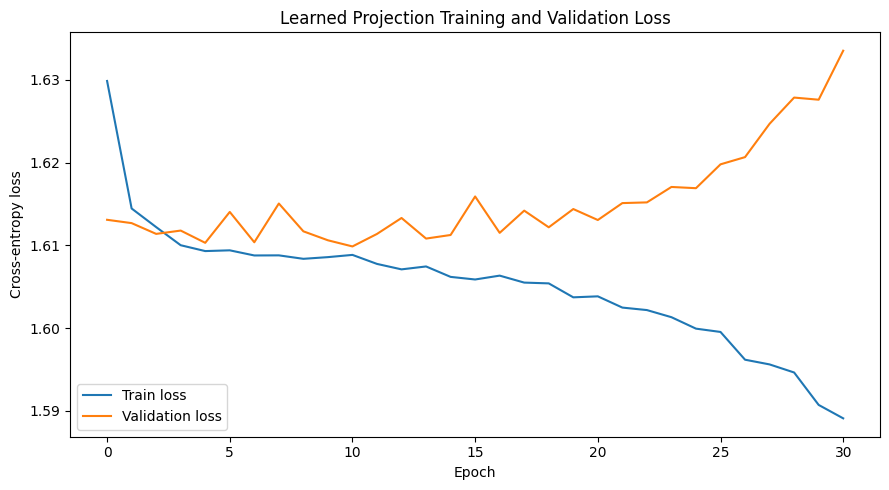

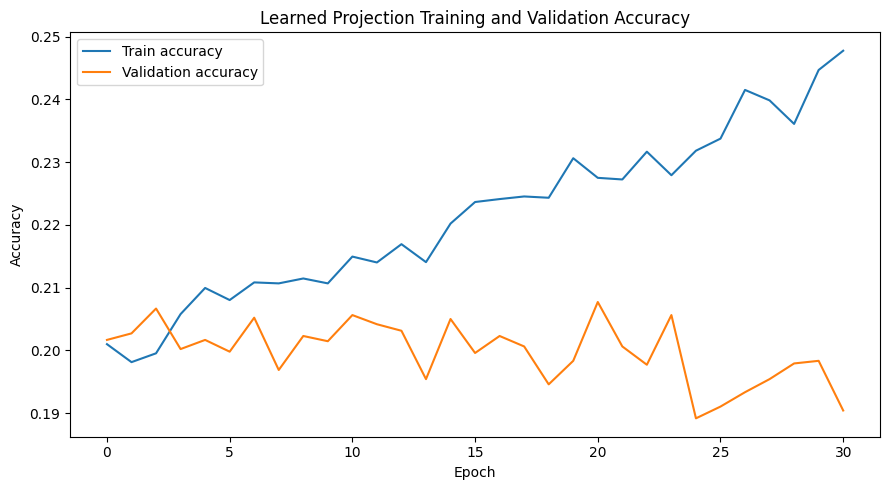

In [26]:
plt.figure(figsize=(9,5))
plt.plot(history["train_loss"],label="Train loss")
plt.plot(history["val_loss"],label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Learned Projection Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
plt.plot(history["train_accuracy"],label="Train accuracy")
plt.plot(history["val_accuracy"],label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learned Projection Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


## 19. Extract learned 256D embeddings

The learned projection is now frozen at its best validation checkpoint.


In [27]:
projection_model.eval()

def extract_projected_embeddings(model,X,batch_size=256):
    loader = DataLoader(TensorDataset(torch.tensor(X,dtype=torch.float32)),batch_size=batch_size,shuffle=False)
    outputs = []
    with torch.inference_mode():
        for (X_batch,) in loader:
            _,z = model(X_batch.to(device))
            outputs.append(z.cpu().numpy())
    return np.vstack(outputs).astype(np.float32)

Z_train = extract_projected_embeddings(projection_model,X_train)
Z_val = extract_projected_embeddings(projection_model,X_val)
Z_test = extract_projected_embeddings(projection_model,X_test)

print("Z_train:",Z_train.shape)
print("Z_val:",Z_val.shape)
print("Z_test:",Z_test.shape)


Z_train: (19200, 256)
Z_val: (4800, 256)
Z_test: (6000, 256)


# Final Evaluation

Only the held-out test set is used here for the final comparison.


In [28]:
def calculate_metrics(y_true,y_pred):
    return {"Accuracy":accuracy_score(y_true,y_pred),"Balanced Accuracy":balanced_accuracy_score(y_true,y_pred),"Macro Precision":precision_score(y_true,y_pred,average="macro",zero_division=0),"Macro Recall":recall_score(y_true,y_pred,average="macro",zero_division=0),"Macro F1":f1_score(y_true,y_pred,average="macro",zero_division=0)}

classifier_pca = LogisticRegression(max_iter=1000,solver="lbfgs",multi_class="auto")
classifier_pca.fit(X_train_pca,y_train)
pred_pca = classifier_pca.predict(X_test_pca)

with torch.inference_mode():
    learned_test_logits,_ = projection_model(torch.tensor(X_test,dtype=torch.float32,device=device))
pred_learned = learned_test_logits.argmax(dim=1).cpu().numpy()

results = pd.DataFrame([calculate_metrics(y_test,pred_1280),calculate_metrics(y_test,pred_pca),calculate_metrics(y_test,pred_learned)],index=["ESM-2 1280","ESM-2 + PCA 256","ESM-2 + Learned 256"])
print(results.round(4))


                     Accuracy  Balanced Accuracy  Macro Precision  \
ESM-2 1280             0.1967             0.1967           0.1969   
ESM-2 + PCA 256        0.1997             0.1997           0.2000   
ESM-2 + Learned 256    0.1947             0.1947           0.2018   

                     Macro Recall  Macro F1  
ESM-2 1280                 0.1967    0.1967  
ESM-2 + PCA 256            0.1997    0.1997  
ESM-2 + Learned 256        0.1947    0.1568  


In [29]:
print("ESM-2 1280 classification report")
print(classification_report(y_test,pred_1280,target_names=class_names,digits=4))

print("ESM-2 + PCA 256 classification report")
print(classification_report(y_test,pred_pca,target_names=class_names,digits=4))

print("ESM-2 + Learned 256 classification report")
print(classification_report(y_test,pred_learned,target_names=class_names,digits=4))


ESM-2 1280 classification report
              precision    recall  f1-score   support

      Enzima     0.2219    0.2158    0.2188      1200
  Estrutural     0.1799    0.1742    0.1770      1200
      Outras     0.2090    0.2008    0.2048      1200
   Receptora     0.1909    0.2058    0.1981      1200
  Transporte     0.1830    0.1867    0.1848      1200

    accuracy                         0.1967      6000
   macro avg     0.1969    0.1967    0.1967      6000
weighted avg     0.1969    0.1967    0.1967      6000

ESM-2 + PCA 256 classification report
              precision    recall  f1-score   support

      Enzima     0.2233    0.2158    0.2195      1200
  Estrutural     0.1860    0.1750    0.1803      1200
      Outras     0.2162    0.2183    0.2172      1200
   Receptora     0.1802    0.1975    0.1885      1200
  Transporte     0.1943    0.1917    0.1930      1200

    accuracy                         0.1997      6000
   macro avg     0.2000    0.1997    0.1997      6000
weight

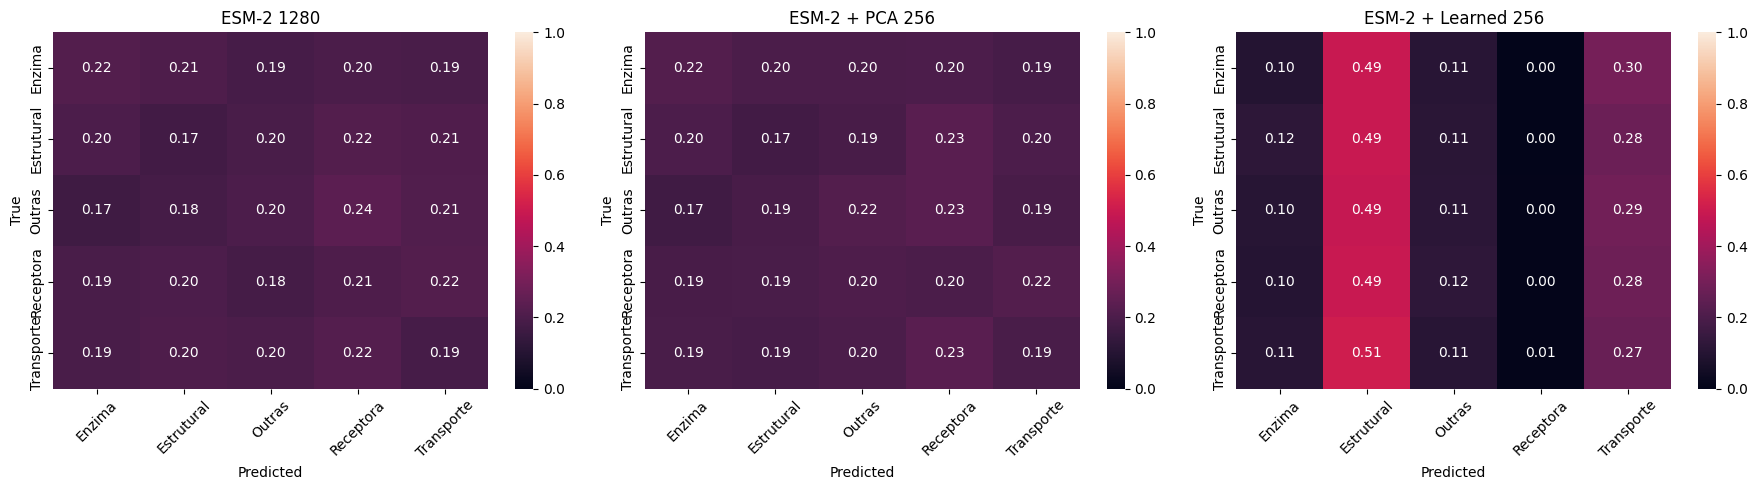

In [30]:
fig,axes = plt.subplots(1,3,figsize=(18,5))

for ax,pred,title in zip(axes,[pred_1280,pred_pca,pred_learned],["ESM-2 1280","ESM-2 + PCA 256","ESM-2 + Learned 256"]):
    cm = confusion_matrix(y_test,pred,normalize="true")
    sns.heatmap(cm,ax=ax,annot=True,fmt=".2f",vmin=0,vmax=1,xticklabels=class_names,yticklabels=class_names)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x",rotation=45)

plt.tight_layout()
plt.show()


# Embedding Analysis on the Reduced Spaces

The same intrinsic analyses can be repeated on PCA-256 and learned-256 embeddings. The learned representation is supervised, so its class separation should be interpreted differently from PCA.


In [31]:
def cosine_nearest_neighbor_agreement(X,y,sample_size=3000):
    sample_size = min(sample_size,len(X))
    idx = np.random.default_rng(SEED).choice(len(X),size=sample_size,replace=False)
    X_sample = X[idx]
    y_sample = y[idx]
    X_norm = X_sample / np.clip(np.linalg.norm(X_sample,axis=1,keepdims=True),1e-12,None)
    similarity = X_norm @ X_norm.T
    np.fill_diagonal(similarity,-np.inf)
    nearest = np.argmax(similarity,axis=1)
    return float(np.mean(y_sample[nearest] == y_sample))

print("ESM-2 1280 nearest-neighbour agreement:",cosine_nearest_neighbor_agreement(X_train,y_train))
print("PCA-256 nearest-neighbour agreement:",cosine_nearest_neighbor_agreement(X_train_pca,y_train))
print("Learned-256 nearest-neighbour agreement:",cosine_nearest_neighbor_agreement(Z_train,y_train))


ESM-2 1280 nearest-neighbour agreement: 0.20266666666666666
PCA-256 nearest-neighbour agreement: 0.19466666666666665
Learned-256 nearest-neighbour agreement: 0.21466666666666667


In [32]:
analysis_summary = pd.DataFrame({"Representation":["ESM-2 1280","PCA-256","Learned-256"],"Dimension":[X_train.shape[1],X_train_pca.shape[1],Z_train.shape[1]],"Nearest-neighbour agreement":[cosine_nearest_neighbor_agreement(X_train,y_train),cosine_nearest_neighbor_agreement(X_train_pca,y_train),cosine_nearest_neighbor_agreement(Z_train,y_train)]})
print(analysis_summary.round(4))


  Representation  Dimension  Nearest-neighbour agreement
0     ESM-2 1280       1280                       0.2027
1        PCA-256        256                       0.1947
2    Learned-256        256                       0.2147


## 20. Save final artefacts

The split indices, label encoder, PCA model, learned projection, and final test results are saved for reproducibility.


In [33]:
np.save(MASTER_DIR / "X_train_pca_256.npy",X_train_pca)
np.save(MASTER_DIR / "X_val_pca_256.npy",X_val_pca)
np.save(MASTER_DIR / "X_test_pca_256.npy",X_test_pca)
np.save(MASTER_DIR / "Z_train_learned_256.npy",Z_train)
np.save(MASTER_DIR / "Z_val_learned_256.npy",Z_val)
np.save(MASTER_DIR / "Z_test_learned_256.npy",Z_test)
joblib.dump(label_encoder,MASTER_DIR / "label_encoder.joblib")
joblib.dump(classifier_1280,MASTER_DIR / "classifier_esm2_1280.joblib")
joblib.dump(classifier_pca,MASTER_DIR / "classifier_pca_256.joblib")
torch.save(projection_model.state_dict(),MASTER_DIR / "learned_projection_256.pt")
results.to_csv(MASTER_DIR / "final_results.csv")

print("Saved artefacts to:",MASTER_DIR)


Saved artefacts to: /kaggle/working/esm2_clean


# Interpretation Guide

### Intrinsic embedding analysis

**PCA explained variance:** measures how much variance is retained after dimensionality reduction. High retained variance means the lower-dimensional representation preserves much of the original geometric variation.

**Cosine similarity:** measures angular similarity between protein embeddings. It is useful because embedding magnitude may be less informative than direction.

**Nearest-neighbour agreement:** measures whether nearby proteins tend to share labels. Higher agreement indicates stronger local class structure.

**Class-centroid similarity:** compares the average embedding of each class. Low cosine similarity between class centroids suggests greater separation.

**K-means + silhouette score:** evaluates whether the embedding naturally forms compact and separated clusters. This is unsupervised and should not be interpreted as classification accuracy.

**UMAP/t-SNE:** visual tools for inspecting local/global structure. Apparent visual separation should be treated as exploratory evidence rather than proof of biological separability.

### Supervised evaluation

**Linear probe:** tests whether class information is directly accessible from frozen ESM-2 embeddings.

**PCA classifier:** tests whether classification performance is retained after unsupervised compression to 256 dimensions.

**Learned projection:** tests whether a supervised neural projection can create a 256-dimensional representation that is useful for the classification task.

### Important interpretation

If accuracy is close to 20% for five balanced classes, performance is close to random guessing. Before concluding that ESM-2 lacks useful information, verify the split, labels, sequence preprocessing, truncation rate, and embedding quality. This notebook removes the previous train/validation/test index mismatch so that the resulting comparison is reproducible.
